# Generation Length Regression
Predict per-sample mean token generation length from prompt embeddings.  
Models: XGBoost, MLP (PyTorch).

In [ ]:
# ── Cell 0: Config ────────────────────────────────────────────────────────────
# Change these two paths to switch experiments (G4 vs G8, 0.6B vs 4B embeddings)

import os

PROJECT_ROOT = os.path.abspath(os.path.join(os.getcwd(), "../../../.."))
ROLLOUT_DIR  = os.path.join(PROJECT_ROOT, "rollouts")
EMBED_DIR    = os.path.join(PROJECT_ROOT, "len_pred", "preprocess", "output")

JSONL_NAME   = "inference_qwen3-4b_math500_G4_B32768_chunk0.jsonl"
EMBED_NAME   = "inference_qwen3-4b_math500_G4_B32768_chunk0__Qwen3-Embedding-4B.parquet"

JSONL_PATH   = f"{ROLLOUT_DIR}/{JSONL_NAME}"
EMBED_PATH   = f"{EMBED_DIR}/{EMBED_NAME}"

# Aggregation over all rollouts for a given sample: "mean" | "median" | "max"
TARGET_AGG   = "mean"

SEED         = 42
TEST_SIZE    = 0.2

# MLP training
MLP_EPOCHS      = 300
MLP_BATCH_SIZE  = 32
MLP_LR          = 1e-3

In [5]:
# ── Imports ───────────────────────────────────────────────────────────────────
import json
import random
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

import xgboost as xgb

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

# Fix seeds globally
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(SEED)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

Device: cuda


In [6]:
# ── Cell 1: Build labels from rollout JSONL ────────────────────────────────────
# Collect token lengths for every rollout, then aggregate per sample_idx.

AGG_FN = {"mean": np.mean, "median": np.median, "max": np.max}[TARGET_AGG]

rollout_lengths = defaultdict(list)   # sample_idx -> [token_len, ...]

with open(JSONL_PATH) as f:
    for line in f:
        d = json.loads(line)
        sid = d["sample_idx"]
        for output in d["method_output"]["outputs"]:
            rollout_lengths[sid].append(len(output["token_ids"]))

labels_df = pd.DataFrame([
    {"sample_idx": sid, "target_length": AGG_FN(lengths)}
    for sid, lengths in sorted(rollout_lengths.items())
])

print(f"Samples: {len(labels_df)}  |  Rollouts/sample: {len(list(rollout_lengths.values())[0])}  |  Agg: {TARGET_AGG}")
labels_df["target_length"].describe()

Samples: 500  |  Rollouts/sample: 128  |  Agg: mean


count      500.000000
mean      4961.551391
std       4393.254565
min        947.414062
25%       2141.152344
50%       3315.800781
75%       6121.005859
max      28997.046875
Name: target_length, dtype: float64

In [7]:
# ── Cell 2: Load embeddings ────────────────────────────────────────────────────
embed_df = pd.read_parquet(EMBED_PATH)
dim_cols = [c for c in embed_df.columns if c != "sample_idx"]
print(f"Embeddings: {len(embed_df)} samples  |  dim: {len(dim_cols)}")
embed_df.head(2)

Embeddings: 500 samples  |  dim: 2560


,sample_idx,dim_0,dim_1,dim_2,dim_3,dim_4,dim_5,dim_6,dim_7,dim_8,...,dim_2550,dim_2551,dim_2552,dim_2553,dim_2554,dim_2555,dim_2556,dim_2557,dim_2558,dim_2559
0,0,-0.000167,-0.02269,0.012596,-0.007061,-0.000838,0.029648,0.039734,0.011330,0.029160,...,-0.000083,0.010086,-0.010361,-0.010269,-0.006779,-0.014091,-0.028534,0.001628,0.027618,0.010078
1,1,-0.000172,-0.00296,0.037048,-0.000588,-0.000779,-0.021133,0.069397,0.019257,0.017517,...,0.001495,-0.022415,-0.027237,0.014961,0.014870,0.013687,0.010300,0.016068,0.035065,0.001836


Merged shape: (500, 2562)


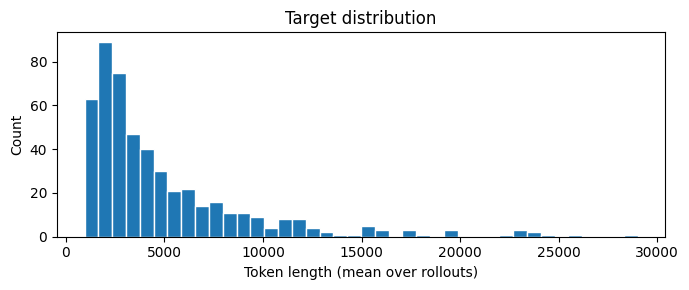

In [8]:
# ── Cell 3: Merge & describe ───────────────────────────────────────────────────
df = embed_df.merge(labels_df, on="sample_idx", how="inner")
print(f"Merged shape: {df.shape}")

fig, ax = plt.subplots(figsize=(7, 3))
ax.hist(df["target_length"], bins=40, edgecolor="white")
ax.set_xlabel(f"Token length ({TARGET_AGG} over rollouts)")
ax.set_ylabel("Count")
ax.set_title("Target distribution")
plt.tight_layout()
plt.show()

In [12]:
# ── Cell 4: Train / test split ─────────────────────────────────────────────────
X = df[dim_cols].values.astype(np.float32)
y = df["target_length"].values.astype(np.float32)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=TEST_SIZE, random_state=SEED
)
print(f"Train: {len(X_train)}  |  Test: {len(X_test)}")

Train: 400  |  Test: 100


In [13]:
# ── Cell 5: Evaluation helper ──────────────────────────────────────────────────
results = {}   # filled by each model section

def evaluate(name: str, y_true: np.ndarray, y_pred: np.ndarray) -> dict:
    rmse = float(np.sqrt(mean_squared_error(y_true, y_pred)))
    mae  = float(mean_absolute_error(y_true, y_pred))
    r2   = float(r2_score(y_true, y_pred))
    print(f"{name:20s}  RMSE={rmse:7.1f}  MAE={mae:7.1f}  R\u00b2={r2:.4f}")
    results[name] = {"RMSE": rmse, "MAE": mae, "R2": r2, "y_pred": y_pred}
    return results[name]

In [14]:
# ── Cell 6: Model 1 — XGBoost ─────────────────────────────────────────────────
xgb_model = xgb.XGBRegressor(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=SEED,
    n_jobs=-1,
    verbosity=0,
)
xgb_model.fit(X_train, y_train)
evaluate("XGBoost", y_test, xgb_model.predict(X_test))

XGBoost               RMSE= 3924.3  MAE= 2410.4  R²=0.3139


{'RMSE': 3924.323635991303,
 'MAE': 2410.416259765625,
 'R2': 0.3139423727989197,
 'y_pred': array([ 7690.233 ,  3971.1304,  3105.2776,  5270.0513,  4468.1064,
         5134.463 ,  5324.752 ,  4504.4507,  5334.5664,  3660.9705,
         5991.5107,  6589.5176,  3902.24  ,  4103.119 ,  6870.3564,
         6614.741 ,  5968.1216,  3800.899 ,  2979.3713,  3591.2456,
         6515.58  ,  3397.2961,  3805.6384,  4733.204 ,  5514.8823,
         7467.1777, 11190.328 ,  2898.8352,  8942.799 ,  5232.449 ,
         7650.995 ,  2964.7527,  2524.4712,  5507.6235,  4694.7666,
         5221.0605,  4561.243 ,  4005.0774,  5388.7104,  5224.26  ,
         2149.9014,  3728.7473, 10634.812 ,  3089.6042,  5319.063 ,
         1932.349 ,  3564.78  ,  4904.854 ,  5718.1626,  3259.5881,
         3639.721 ,  3603.538 ,  3619.6775,  4181.1943,  8167.867 ,
         3842.6733,  1376.367 ,  6712.8726,  9675.763 ,  7472.077 ,
         8648.615 ,  2514.471 ,  7727.6333,  8293.412 ,  2448.138 ,
         4244.851 ,  275

  Epoch  20/300  RMSE=4124.2
  Epoch  40/300  RMSE=3636.5
  Epoch  60/300  RMSE=3163.0
  Epoch  80/300  RMSE=2766.2
  Epoch 100/300  RMSE=2466.9
  Epoch 120/300  RMSE=2130.1
  Epoch 140/300  RMSE=1961.7
  Epoch 160/300  RMSE=1498.3
  Epoch 180/300  RMSE=1276.9
  Epoch 200/300  RMSE=1075.6
  Epoch 220/300  RMSE=966.5
  Epoch 240/300  RMSE=863.2
  Epoch 260/300  RMSE=823.2
  Epoch 280/300  RMSE=707.8
  Epoch 300/300  RMSE=660.3
MLP                   RMSE= 3811.6  MAE= 2249.9  R²=0.3528


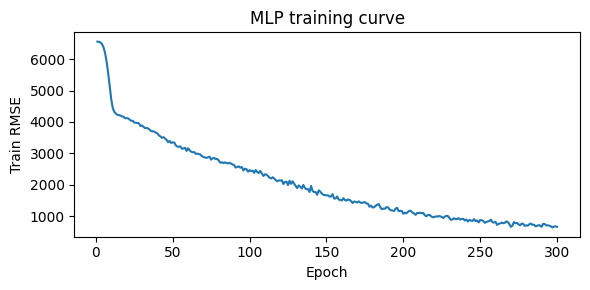

In [21]:
# ── Cell 7: Model 2 — MLP (PyTorch) ───────────────────────────────────────────

class MLP(nn.Module):
    """3-layer MLP for scalar regression. Extend by changing hidden_dims."""
    def __init__(self, input_dim: int, hidden_dims: list = [512, 128], dropout: float = 0.2):
        super().__init__()
        layers = []
        in_dim = input_dim
        for h in hidden_dims:
            layers += [nn.Linear(in_dim, h), nn.ReLU(), nn.Dropout(dropout)]
            in_dim = h
        layers.append(nn.Linear(in_dim, 1))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x).squeeze(-1)


def train_mlp(X_tr, y_tr, epochs=MLP_EPOCHS, batch_size=MLP_BATCH_SIZE, lr=MLP_LR):
    torch.manual_seed(SEED)
    model = MLP(input_dim=X_tr.shape[1]).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    dataset = TensorDataset(
        torch.from_numpy(X_tr).to(DEVICE),
        torch.from_numpy(y_tr).to(DEVICE),
    )
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True)

    loss_history = []
    model.train()
    for epoch in range(1, epochs + 1):
        epoch_loss = 0.0
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()
            epoch_loss += loss.item() * len(xb)
        loss_history.append(epoch_loss / len(X_tr))
        if epoch % 20 == 0:
            print(f"  Epoch {epoch:3d}/{epochs}  RMSE={loss_history[-1]**0.5:.1f}")

    return model, loss_history


mlp_model, loss_history = train_mlp(X_train, y_train)

mlp_model.eval()
with torch.no_grad():
    y_pred_mlp = mlp_model(torch.from_numpy(X_test).to(DEVICE)).cpu().numpy()
evaluate("MLP", y_test, y_pred_mlp)

# Loss curve
fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(range(1, MLP_EPOCHS + 1), [v**0.5 for v in loss_history])
ax.set_xlabel("Epoch")
ax.set_ylabel("Train RMSE")
ax.set_title("MLP training curve")
plt.tight_layout()
plt.show()

           RMSE     MAE   R2
XGBoost 3924.32 2410.42 0.31
MLP     3811.59 2249.91 0.35


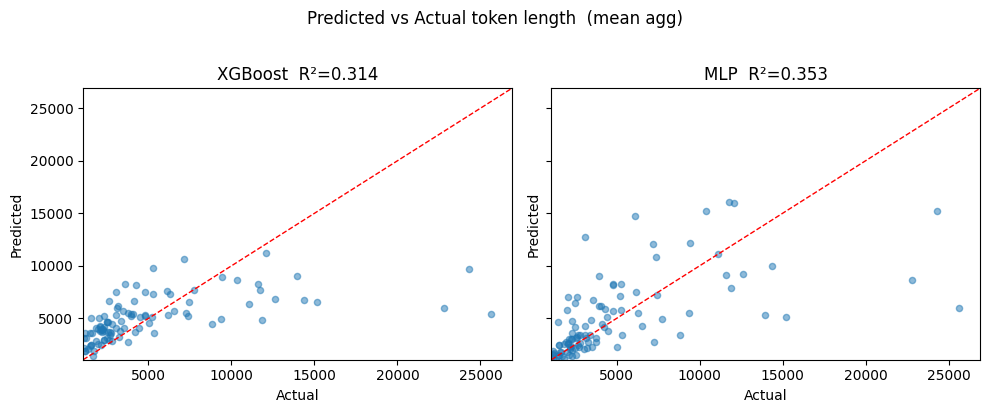

In [22]:
# ── Cell 8: Comparison ─────────────────────────────────────────────────────────

# Metrics table
metrics_df = pd.DataFrame(
    {name: {k: v for k, v in vals.items() if k != "y_pred"} for name, vals in results.items()}
).T
print(metrics_df.to_string(float_format="{:.2f}".format))

# Scatter: predicted vs actual
model_names = list(results.keys())
fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 4), sharey=True)
if len(model_names) == 1:
    axes = [axes]

lim = (float(y_test.min()) * 0.95, float(y_test.max()) * 1.05)
for ax, name in zip(axes, model_names):
    y_pred = results[name]["y_pred"]
    ax.scatter(y_test, y_pred, alpha=0.5, s=20)
    ax.plot(lim, lim, "r--", linewidth=1)
    ax.set_xlim(lim); ax.set_ylim(lim)
    ax.set_xlabel("Actual")
    ax.set_ylabel("Predicted")
    ax.set_title(f"{name}  R\u00b2={results[name]['R2']:.3f}")

plt.suptitle(f"Predicted vs Actual token length  ({TARGET_AGG} agg)", y=1.02)
plt.tight_layout()
plt.show()